HỆ THỐNG TƯ VẤN - Hybrid

In [1]:
from pymongo import MongoClient
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np 
from nltk.stem import PorterStemmer
import re

GIAI ĐOẠN 1: TRUY XUẤT DỮ LIỆU TỪ BIGQUERY

In [2]:
import bigframes.pandas as bf

bf.options.bigquery.location = "US" #this variable is set based on the dataset you chose to query
bf.options.bigquery.project = "project2-423018" #this variable is set based on the dataset you chose to query

In [3]:
initial_df = bf.read_gbq("project2-423018.glamira_dataset_models.Hybrid")

GIAI ĐOẠN 2: EDA - TIỀN XỬ LÍ DỮ LIỆU

Bước 1: Tìm Hiểu Sơ Lược Về Dữ Liệu

In [6]:
# dataframe trích xuất từ MongoDB
initial_df.head()

,email_address,final_product_id,ip,full_date,option,collection,final_price,product_name
0,louisa.leplanois@sfr.fr,80261,109.10.178.71,2020-04-21,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,0.0,Wedding Ring Brilliant Couple
1,laurentiustroe@ymail.com,80261,109.102.219.146,2020-06-04,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,0.0,Wedding Ring Brilliant Couple
2,Ginmitchell@hotmail.com,80261,109.156.20.251,2020-05-30,[],checkout,0.0,Wedding Ring Brilliant Couple
3,Ginmitchell@hotmail.com,80261,109.156.20.251,2020-05-31,[],view_shopping_cart,0.0,Wedding Ring Brilliant Couple
4,Ginmitchell@hotmail.com,80261,109.156.20.251,2020-05-30,[],checkout_success,0.0,Wedding Ring Brilliant Couple


In [7]:
# kiểu dữ liệu các cột của initial_df
initial_df.dtypes

email_address        object
final_product_id     object
ip                   object
full_date            object
option               object
collection           object
final_price         float64
product_name         object
dtype: object

In [8]:
# Danh sách giá trị duy nhất của cột 'collection'
initial_df['collection'].unique()

array(['view_product_detail', 'checkout', 'view_shopping_cart',
       'checkout_success', 'select_product_option_quality',
       'select_product_option', 'add_to_cart_action',
       'back_to_product_action'], dtype=object)

In [9]:
# Số lượng 'final_product_id' có trong dữ liệu, mỗi 'final_product_id' là một sản phẩm cố định
initial_df['final_product_id'].nunique()

12645

In [10]:
# Số lượng người dùng (có tài khoản với định danh email)
initial_df['email_address'].nunique()

25534

In [11]:
# Số lượng người khác nhau dùng đã mua hàng thành công 
num_unique_emails = initial_df[initial_df['collection'] == 'checkout_success']['email_address'].nunique()
print(f"Số lượng người dùng khác nhau đã mua hàng thành công': {num_unique_emails}")

Số lượng người dùng khác nhau đã mua hàng thành công': 14432


In [12]:
# Số lượng hành động đã mua hàng thành công
count_CheckoutSuccess = (initial_df['collection'] == 'checkout_success').sum()
print(f"Số lượng đơn hàng thành công: {count_CheckoutSuccess}")

# Tính tổng số dòng dữ liệu
total_rows = len(initial_df)

# Tính tỷ lệ phần trăm hành động 'checkout_success'
CheckoutSuccess_percentage = (count_CheckoutSuccess / total_rows) * 100

# In kết quả
print(f"Tỉ lệ đơn hàng thành công trong tập dữ liệu: ({CheckoutSuccess_percentage:.2f}%)")

Số lượng đơn hàng thành công: 18000
Tỉ lệ đơn hàng thành công trong tập dữ liệu: (1.92%)


Bước 2: Tiền Xử Lí Dữ Liệu

In [13]:
# Xóa một số tương tác không có ý nghĩa với sản phẩm
initial_df = initial_df[~initial_df['final_product_id'].isin(['103896', '97507'])]

In [14]:
initial_df.shape

(931996, 8)

- 1. Xử lí cột 'final_price'

In [15]:
# phân tích sơ lược cột 'final_price'
# Tính số dòng thiếu giá (null, rỗng, hoặc bằng 0)
num_missing_final_price = (
    initial_df['final_price'].isna().sum() +
    (initial_df['final_price'] == '').sum() +
    (initial_df['final_price'] == 0).sum()
)

print(f"Số lượng dòng bị null, rỗng hoặc có giá trị 0 (ban đầu): {num_missing_final_price}")

# Tổng số dòng dữ liệu
total_rows = len(initial_df)

# Tính tỷ lệ phần trăm dòng thiếu giá
missing_percentage = (num_missing_final_price / total_rows) * 100

print(f"Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (ban đầu): {missing_percentage:.2f}%")

Số lượng dòng bị null, rỗng hoặc có giá trị 0 (ban đầu): 915411
Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (ban đầu): 98.22%


In [16]:
# Tạo DataFrame phụ lưu final_product_id và final_price với điều kiện giá trị hợp lệ
valid_price_df = initial_df[
    initial_df['final_product_id'].notna() & (initial_df['final_product_id'] != '') &
    initial_df['final_price'].notna() & (initial_df['final_price'] != '') &
    (initial_df['final_price'] != 0)
][['final_product_id', 'final_price']]

# Nếu muốn loại trùng lặp (chỉ lấy mỗi final_product_id 1 giá), bạn có thể dùng:
valid_price_df = valid_price_df.drop_duplicates(subset='final_product_id')

print(f"Tổng số sản phẩm có giá hợp lệ: {len(valid_price_df)}")

Tổng số sản phẩm có giá hợp lệ: 4279


In [17]:
# Tạo dictionary ánh xạ từ final_product_id → final_price
price_mapping = valid_price_df.set_index('final_product_id')['final_price'].to_dict()

# Hàm điền giá: chỉ thay nếu final_price bị thiếu, rỗng hoặc bằng 0
def fill_price(row):
    if pd.isna(row['final_price']) or row['final_price'] == '' or row['final_price'] == 0:
        return price_mapping.get(row['final_product_id'], row['final_price'])
    return row['final_price']

# Áp dụng hàm điền giá cho toàn bộ dataframe
initial_df['final_price'] = initial_df.apply(fill_price, axis=1)

# Kiểm tra kết quả
num_missing_final_price_after = (
    initial_df['final_price'].isna().sum() +
    (initial_df['final_price'] == '').sum() +
    (initial_df['final_price'] == 0).sum()
)

# Tính tỷ lệ phần trăm dòng thiếu giá
missing_percentage_after = (num_missing_final_price_after / total_rows) * 100

print(f"Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (sau ánh xạ): {missing_percentage_after:.2f}%")

Tỉ lệ dữ liệu có 'final_price' bị thiếu giá sản phẩm (sau ánh xạ): 16.81%


In [18]:
# Điền các dòng vẫn còn bị thiếu giá sản phẩm bằng giá trị trung vị (median) của cột
price_median = initial_df['final_price'].median()
initial_df['final_price'] = initial_df['final_price'].apply(lambda x: price_median if pd.isna(x) or x == '' or x == 0 else x)
print(f"Đã xử lý cột 'final_price'. Giá trị trung vị để điền là: {price_median:.2f} USD")

Đã xử lý cột 'final_price'. Giá trị trung vị để điền là: 463.87 USD


In [19]:
initial_df['final_price'].describe()

count    9.319960e+05
mean     4.772314e+03
std      6.473193e+04
min      7.500000e+00
25%      3.745440e+02
50%      4.638700e+02
75%      9.328000e+02
max      9.813373e+06
Name: final_price, dtype: float64

In [20]:
# loại bỏ đi 1 phần outlier
q_low = initial_df['final_price'].quantile(0.05)
q_high = initial_df['final_price'].quantile(0.95)
filtered_df = initial_df[(initial_df['final_price'] >= q_low) & (initial_df['final_price'] <= q_high)]

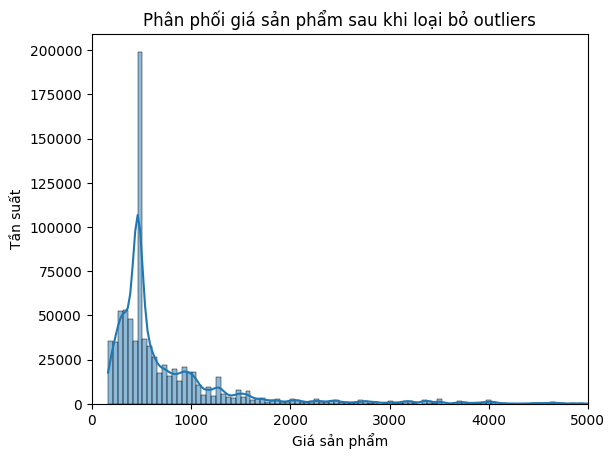

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(filtered_df['final_price'], bins=100, kde=True)
plt.xlim(0, 5000)  # zoom vào khoảng dưới 5000 để dễ xem
plt.title("Phân phối giá sản phẩm sau khi loại bỏ outliers")
plt.xlabel("Giá sản phẩm")
plt.ylabel("Tần suất")
plt.show()


📌 Nhận định quan trọng
Thị trường có mức giá chính phổ biến là thấp và trung bình:

~70–80% sản phẩm nằm dưới mức 1,000.

Đây là nhóm sản phẩm bình dân, có thể coi là mainstream segment.

Các sản phẩm cao cấp có giá trị cao nhưng ít:

- Các mức >2,000 là sản phẩm niche hoặc luxury → nên phân biệt rõ khi phân loại.
- Chia theo quartile (qcut) sẽ không hợp lý:
Vì số lượng sản phẩm rẻ rất nhiều → sẽ khiến các bin bị bóp méo hoặc mất ý nghĩa thực tế.
- Do đó nên chọn phương án định nghĩa thủ công

In [22]:
# Hướng tiếp cận tự định nghĩa price_bin
bins = [0, 300, 800, 2000, float('inf')]
labels = ['price_low', 'price_medium', 'price_high', 'price_premium']
initial_df['price_bin'] = pd.cut(initial_df['final_price'], bins=bins, labels=labels, right=False)

In [23]:
# phân bổ khoảng giá sản phẩm
initial_df['price_bin'].value_counts()

price_bin
price_medium     492381
price_high       184430
price_low        158291
price_premium     96894
Name: count, dtype: int64

- 2. Xử lí cột 'ip'

In [24]:
# chuẩn hóa địa chỉ 'ip' thành mã quốc gia
# thư viện hỗ trợ
import geoip2.database
from tqdm import tqdm

# Cấu hình đường dẫn tới file database
GEOIP_DB_PATH = 'GeoLite2-Country.mmdb'

# Khởi tạo tqdm để tích hợp với pandas
tqdm.pandas()

# Tạo một đối tượng reader
try:
    reader = geoip2.database.Reader(GEOIP_DB_PATH)

    def get_country_from_ip(ip):
        """
        Hàm nhận vào một địa chỉ IP, trả về mã quốc gia (ISO code).
        Trả về 'Unknown' nếu không tìm thấy hoặc IP không hợp lệ.
        """
        try:
            # reader.country() trả về một đối tượng chứa thông tin quốc gia
            response = reader.country(ip)
            # Lấy mã ISO (ví dụ: 'US', 'VN', 'DE')
            return response.country.iso_code
        except (geoip2.errors.AddressNotFoundError, ValueError):
            # Lỗi xảy ra nếu IP là địa chỉ nội bộ (private) hoặc không tìm thấy trong 'geoip2.database'
            return 'Unknown'

    print("Bắt đầu chuyển đổi IP sang mã quốc gia...")
    # Sử dụng .progress_apply để hiển thị thanh tiến trình
    initial_df['country'] = initial_df['ip'].progress_apply(get_country_from_ip)
    
    print("\n✅ Chuyển đổi hoàn tất. Đã tạo cột 'country'.")
    
    # Đóng reader sau khi hoàn tất
    reader.close()

except FileNotFoundError:
    print(f"LỖI: Không tìm thấy file database '{GEOIP_DB_PATH}'.")
    print("Vui lòng tải file GeoLite2-Country.mmdb và đặt vào đúng thư mục.")
    # Tạo cột 'country' với giá trị mặc định để các cell sau không bị lỗi
    initial_df['country'] = 'Not_Available'

Bắt đầu chuyển đổi IP sang mã quốc gia...


100%|██████████| 931996/931996 [00:20<00:00, 46368.28it/s]


✅ Chuyển đổi hoàn tất. Đã tạo cột 'country'.


In [25]:
# danh sách duy nhất các mã 'quốc gia' có tương tác trong dữ liệu
initial_df['country'].unique()

array(['FR', 'RO', 'GB', 'DE', 'US', 'PE', 'PL', 'DK', 'AT', 'IE', 'AU',
       'CH', 'IT', 'ES', 'SE', 'BE', 'SG', 'CA', 'HK', 'HU', 'CO', 'CL',
       'MX', 'GT', 'ZA', 'PT', 'NL', 'FI', 'NO', 'LV', 'NZ', 'CR', 'BO',
       'SK', 'LT', 'TR', 'HR', 'MD', 'NG', 'SI', 'GE', 'MT', 'IN', 'AR',
       'AE', 'PH', 'BG', 'CZ', 'EE', 'VN', 'SV', 'GR', 'MG', 'AO', 'JP',
       'LU', 'CU', 'UY', 'UA', 'BR', 'Unknown', 'SA', 'IR', 'TN', 'QA',
       'IQ', 'MY', 'RS', 'GP', 'EC', 'KE', 'RU', 'KZ', 'DO', 'GL', 'DZ',
       'LK', 'LI', 'IL', 'RE', None, 'KR', 'HN', 'JE', 'MK', 'AD', 'OM',
       'NP', 'EG', 'SR', 'TT', 'TW', 'MA', 'PK', 'CG', 'GH', 'IM', 'TH',
       'GF', 'KG', 'KY', 'AF', 'UG', 'SY', 'BF', 'SZ', 'FO', 'AG', 'BA',
       'BY', 'IS', 'MQ', 'CY', 'GA', 'JO', 'KW', 'ME', 'ID', 'ML', 'SM',
       'VC', 'CM', 'DJ', 'PR', 'BW', 'BD', 'SN', 'MZ', 'PY', 'NC', 'CI',
       'PS', 'CN', 'XK', 'CV', 'PG', 'AL', 'PF', 'VE', 'AW', 'BQ', 'LB',
       'AM', 'BH'], dtype=object)

In [26]:
print(f"số lượng quốc gia có tương tác: ({initial_df['country'].nunique()})")

print(f"số lượng dòng có 'country' rỗng: ({initial_df['country'].isna().sum()})")

print(f"số lượng dòng có 'country' không xác định được: ({(initial_df['country'] == 'Unknown').sum()})")

số lượng quốc gia có tương tác: (143)
số lượng dòng có 'country' rỗng: (120)
số lượng dòng có 'country' không xác định được: (256)


In [27]:
# Phân tích insight từ cột 'country'

print("--- Bắt đầu: Phân tích Dữ liệu Vị trí Người dùng ---")

if 'country' in initial_df.columns and 'Not_Available' not in initial_df['country'].unique():
    
    # 1. Phân bổ người dùng theo quốc gia
    country_distribution = initial_df['country'].value_counts()
    print("\nTop 10 quốc gia có nhiều tương tác nhất:")
    print(country_distribution.head(10))
    
    # 2. Phân tích hành vi theo các quốc gia chính
    # Chỉ xét các quốc gia có lượng dữ liệu đủ lớn (ví dụ: hơn 15000 tương tác) để kết quả thống kê có ý nghĩa
    major_countries = country_distribution[country_distribution > 15000].index.tolist()
    print(f"\n--- Phân tích Sâu hơn cho các Quốc gia Chính: {major_countries} ---")

    # Tạo một DataFrame tạm thời chỉ chứa các quốc gia chính
    df_major_countries = initial_df[initial_df['country'].isin(major_countries)].copy()

    # 3. Phân tích Tỷ lệ Chuyển đổi (Conversion Rate)
    print("\n--- Phân tích Tỷ lệ Chuyển đổi theo Quốc gia ---")
    # Tính tỷ lệ % của 'checkout_success' trong các tương tác của mỗi quốc gia
    conversion_rates = df_major_countries.groupby('country')['collection'].apply(
        lambda x: (x == 'checkout_success').mean() * 100
    ).sort_values(ascending=False)
    
    print("Tỷ lệ chuyển đổi (checkout_success / tổng tương tác) theo quốc gia (%):")
    print(conversion_rates.round(2))

    # 4. Phân tích Giá trị Đơn hàng Trung bình (Average Order Value - AOV)
    print("\n--- Phân tích Mức chi tiêu theo Quốc gia ---")
    
    # Chỉ xét các giao dịch thành công để tính AOV
    df_success = df_major_countries[df_major_countries['collection'] == 'checkout_success'].copy()
    avg_order_value = df_success.groupby('country')['final_price'].mean().sort_values(ascending=False)
    print("Giá trị đơn hàng trung bình (USD) cho các giao dịch thành công theo quốc gia:")
    print(avg_order_value.round(2))

else:
    print("Cột 'country' chưa được tạo hoặc có lỗi. Vui lòng chạy lại bước chuyển đổi IP.")

--- Bắt đầu: Phân tích Dữ liệu Vị trí Người dùng ---

Top 10 quốc gia có nhiều tương tác nhất:
country
DE    102098
US     95923
GB     63864
FR     58180
IT     48067
CA     45120
SE     42250
CH     33347
NL     29623
AU     28535
Name: count, dtype: int64

--- Phân tích Sâu hơn cho các Quốc gia Chính: ['DE', 'US', 'GB', 'FR', 'IT', 'CA', 'SE', 'CH', 'NL', 'AU', 'MX', 'DK', 'BE', 'RO', 'ES', 'TR', 'CL', 'AT', 'PL'] ---

--- Phân tích Tỷ lệ Chuyển đổi theo Quốc gia ---
Tỷ lệ chuyển đổi (checkout_success / tổng tương tác) theo quốc gia (%):
country
DE    2.89
GB    2.81
CH    2.58
AT    2.49
DK    2.38
FR    2.22
NL    2.13
AU    2.10
BE    1.89
ES    1.75
SE    1.62
IT    1.44
PL    1.28
US    1.21
RO    1.15
CA    1.12
MX    0.98
CL    0.95
TR    0.70
Name: collection, dtype: float64

--- Phân tích Mức chi tiêu theo Quốc gia ---
Giá trị đơn hàng trung bình (USD) cho các giao dịch thành công theo quốc gia:
country
MX    9873.62
PL    8911.63
AU    7053.08
SE    4267.42
BE    4224.93
C

Bước: Phân cụm 'country' bằng thuật toán k-means
- Danh sách các quốc gia có hành vi tiêu dùng như:
    + conversion_rate: tỷ lệ chuyển đổi thành giao dịch
    + avg_order_value: giá trị đơn hàng trung bình
- Ý tưởng: Dùng phương pháp phân cụm (clustering) để nhóm các quốc gia có đặc điểm hành vi tương đồng thành từng vùng thị trường/nhóm kinh tế
- Phương pháp: K-Means → phù hợp vì đơn giản, trực quan, dữ liệu định lượng
- Triển khai: từ tiền xử lý đến phân cụm và sử dụng kết quả cho báo cáo hoặc mô hình hóa

--- Bắt đầu: Phân cụm các quốc gia theo hành vi ---


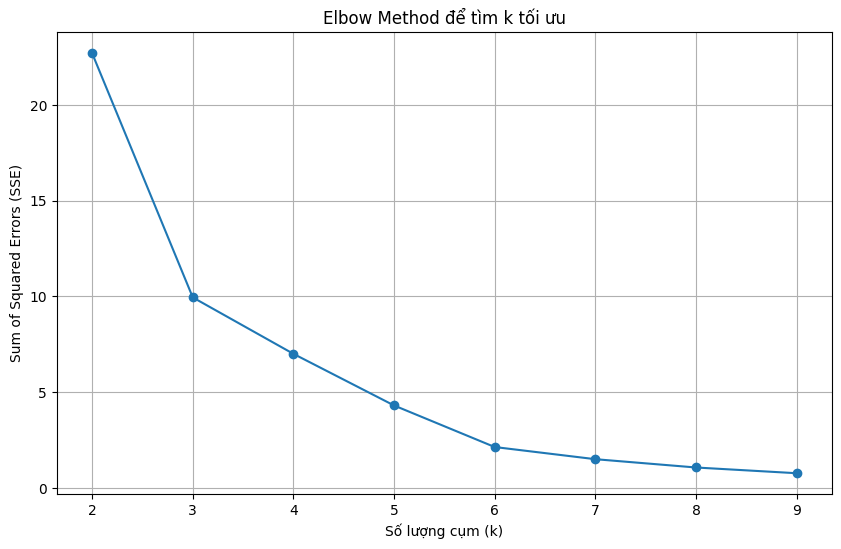


--- Kết quả Phân thành 3 Cụm (Vùng kinh tế) ---

--- Cụm 0 ---
Số lượng quốc gia: 5
Các quốc gia: ['AU', 'BE', 'MX', 'PL', 'SE']
Đặc điểm trung bình của cụm:
conversion_rate       1.57
avg_order_value    6866.14
dtype: float64

--- Cụm 1 ---
Số lượng quốc gia: 6
Các quốc gia: ['CA', 'CL', 'IT', 'RO', 'TR', 'US']
Đặc điểm trung bình của cụm:
conversion_rate       1.09
avg_order_value    1173.04
dtype: float64

--- Cụm 2 ---
Số lượng quốc gia: 8
Các quốc gia: ['AT', 'CH', 'DE', 'DK', 'ES', 'FR', 'GB', 'NL']
Đặc điểm trung bình của cụm:
conversion_rate       2.41
avg_order_value    1755.17
dtype: float64


✅ Đã tạo xong `country_to_region_map` để sẵn sàng tích hợp vào pipeline.


In [28]:
# Phân cụm 'country' bằng k-means

# thư viện hỗ trợ
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("--- Bắt đầu: Phân cụm các quốc gia theo hành vi ---")

# Đảm bảo 'conversion_rates' và 'avg_order_value' đã được tạo
if 'conversion_rates' in locals() and 'avg_order_value' in locals():
    
    # 1. Tạo DataFrame chứa các chỉ số của quốc gia
    country_metrics_df = pd.DataFrame({
        'conversion_rate': conversion_rates,
        'avg_order_value': avg_order_value
    }).dropna()

    if not country_metrics_df.empty:
        # --- XỬ LÝ DỮ LIỆU NGOẠI LỆ ---
        # Áp dụng log transform cho AOV để giảm tác động của các giá trị quá lớn
        country_metrics_df['aov_log'] = np.log1p(country_metrics_df['avg_order_value'])
        
        # Sử dụng 2 cột đã xử lý để phân cụm
        data_for_clustering = country_metrics_df[['conversion_rate', 'aov_log']]
        
        # 2. Chuẩn hóa dữ liệu
        scaler = StandardScaler()
        scaled_metrics = scaler.fit_transform(data_for_clustering)

        # 3. Tìm số cụm (k) tối ưu bằng phương pháp "Elbow Method"
        sse = []
        k_range = range(2, 10) # Thử từ 2 đến 10 cụm
        for k in k_range:
            kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
            kmeans.fit(scaled_metrics)
            sse.append(kmeans.inertia_)

        # Vẽ biểu đồ Elbow
        plt.figure(figsize=(10, 6))
        plt.plot(k_range, sse, marker='o')
        plt.xlabel('Số lượng cụm (k)')
        plt.ylabel('Sum of Squared Errors (SSE)')
        plt.title('Elbow Method để tìm k tối ưu')
        plt.xticks(k_range)
        plt.grid(True)
        plt.show()
        
        # --- BƯỚC TIẾP THEO SAU KHI XEM BIỂU ĐỒ ---
        # TODO: Dựa vào biểu đồ 'khuỷu tay' ở trên, chọn một giá trị 'k' tối ưu và 
        OPTIMAL_K = 3   # là giá trị 'k' tối ưu

        # 4. Chạy K-Means với số k đã chọn
        kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
        country_metrics_df['region_cluster'] = kmeans_final.fit_predict(scaled_metrics)

        print(f"\n--- Kết quả Phân thành {OPTIMAL_K} Cụm (Vùng kinh tế) ---")
        # In ra các quốc gia trong mỗi cụm
        for i in range(OPTIMAL_K):
            print(f"\n--- Cụm {i} ---")
            cluster_countries = country_metrics_df[country_metrics_df['region_cluster'] == i]
            print(f"Số lượng quốc gia: {len(cluster_countries)}")
            print(f"Các quốc gia: {cluster_countries.index.tolist()}")
            print("Đặc điểm trung bình của cụm:")
            print(cluster_countries[['conversion_rate', 'avg_order_value']].mean().round(2))

        # 5. Tạo một dictionary để map từ quốc gia sang cụm
        country_to_region_map = country_metrics_df['region_cluster'].to_dict()
        print("\n\n✅ Đã tạo xong `country_to_region_map` để sẵn sàng tích hợp vào pipeline.")
        
    else:
        print("Không có đủ dữ liệu để tạo country_metrics_df.")

else:
    print("LỖI: Chưa có dữ liệu 'conversion_rates' và 'avg_order_value'. Vui lòng chạy cell phân tích ở bước trước.")

In [29]:
# Thêm thông tin cho cột 'region_id'
if 'country_to_region_map' in locals():
    initial_df['region_id'] = initial_df['country'].map(country_to_region_map)
    # Điền giá trị mặc định cho các quốc gia không có trong map (ví dụ: 'unknown')
    initial_df['region_id'] = initial_df['region_id'].fillna('unknown_region')
    print("Đã thêm cột 'region_id' vào initial_df.")
    # Chuyển đổi region_id sang kiểu chuỗi để đảm bảo tính nhất quán
    initial_df['region_id'] = initial_df['region_id'].astype(str)
else:
    print("LỖI: Không tìm thấy 'country_to_region_map'. Vui lòng chạy lại cell phân cụm K-Means.")

Đã thêm cột 'region_id' vào initial_df.


- 3. xử lí cột 'collection'

In [30]:
# Tự tạo danh mục 'rating'
interaction_weights = {
    'checkout_success': 5.0,                # Tín hiệu cao nhất - thanh toán thành công
    'checkout': 4.0,                        # Bắt đầu thanh toán
    'add_to_cart_action': 3.0,              # Ý định mua rất cao - thêm sản phẩm vào giỏ hàng
    'select_product_option': 2.0,           # Quan tâm sâu - chọn tùy chọn cho sản phẩm
    'select_product_option_quality': 2.0,   # Quan tâm sâu - chọn tùy chọn cho sản phẩm
    'view_shopping_cart': 1.5,              # Xem giỏ hàng
    'back_to_product_action': 1.2,          # Quan tâm trở lại
    'view_product_detail': 1.0,             # Quan tâm cơ bản - trang chi tiết thông tin sản phẩm
}

In [31]:
initial_df['rating'] = initial_df['collection'].map(interaction_weights).fillna(0)
print("\nĐã cập nhật cột 'rating' với thang điểm mới.")
print("Phân bổ số lượng các loại rating mới:")
print(initial_df['rating'].value_counts())


Đã cập nhật cột 'rating' với thang điểm mới.
Phân bổ số lượng các loại rating mới:
rating
2.0    389983
1.0    276770
1.5    164589
4.0     64726
3.0     18873
5.0     17019
1.2        36
Name: count, dtype: int64


- 4. Tạo category sản phẩm

In [32]:
# Hàm phân loại category sản phẩm
# Các bước xử lý ngầm: kiểm tra các từ phổ biến trong tên sản phẩm -> đưa ra nhận định chủ quan các từ nào cùng thuộc một danh mục sản phẩm

def get_category_from_name(product_name):
    """
    Hàm nhận vào tên sản phẩm và trả về danh mục dựa trên bộ quy tắc đã được nâng cấp.
    Danh mục trả về sử dụng tiếng Anh.
    """
    # Bộ quy tắc nâng cấp, bao gồm cả từ khóa đa ngôn ngữ
    category_keywords = {
        'ring': [                                         # nhẫn
            'ring', 'rings', 'band',                      # Tiếng Anh
            'trauring', 'herrenring', 'damenring',        # Tiếng Đức
            'ehering', 'verlobungsring', 'ringe',         # Tiếng Đức
            'inel',                                       # Tiếng Rumani
            'bague', 'alliance',                          # Tiếng Pháp
            'vihkisormus',                                # Tiếng Phần Lan
            'anillo'                                      # Tiếng Tây Ban Nha
        ],
        'necklace': ['pendant', 'necklace', 'chain'],   # dây chuyền
        'earring': ['earring', 'earrings', 'studs'],    # bông tai
        'bracelet': ['bracelet', 'armband'],            # lắc tay
        'anklet': ['anklet'],                           # lắc chân
        'brooch': ['brooch'],                           # trâm cài áo
        'cufflinks': ['cufflinks', 'cufflink'],         # khuy áo
        'set': ['set'],                                 # bộ sản phẩm
        'kids': ['childrens', "children's", 'kids'],    # sản phẩm dành cho trẻ em
        'accessory': ['pin', 'tiepin']                  # phụ kiện 
    }

    # Kiểm tra input hợp lệ
    if not isinstance(product_name, str):
        return 'unknown'
    
    # Chuyển tên sản phẩm về chữ thường để tìm từ khóa
    name_lower = product_name.lower()

    # Duyệt qua từng danh mục và kiểm tra xem tên sản phẩm có chứa từ khóa nào không
    for category, keywords in category_keywords.items():
        for keyword in keywords:
            # Sử dụng regex để đảm bảo khớp từ đúng ranh giới từ (tránh match sai)
            if re.search(r'\b' + re.escape(keyword) + r'\b', name_lower):
                return category

    # Trường hợp không khớp với bất kỳ danh mục nào đã định nghĩa
    return 'other'  # danh mục khác


In [33]:
initial_df['category'] = initial_df['product_name'].apply(get_category_from_name)

# Kiểm tra lại kết quả phân bổ
print("\nPhân bổ số lượng tương tác theo 'category':")
print(initial_df['category'].value_counts())


Phân bổ số lượng tương tác theo 'category':
category
ring         644654
necklace     113258
earring       94478
other         42610
bracelet      27549
set            4465
accessory      1644
cufflinks      1161
anklet         1028
kids            742
brooch          407
Name: count, dtype: int64


In [34]:
print('Dataframe dữ liệu sau khi EDA')
initial_df.head()

Dataframe dữ liệu sau khi EDA


,email_address,final_product_id,ip,full_date,option,collection,final_price,product_name,price_bin,country,region_id,rating,category
0,louisa.leplanois@sfr.fr,80261,109.10.178.71,2020-04-21,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,323.4,Wedding Ring Brilliant Couple,price_medium,FR,2.0,1.0,ring
1,laurentiustroe@ymail.com,80261,109.102.219.146,2020-06-04,"[{'option_label': 'alloy', 'option_id': '45841', 'value_id': '204363'}]",view_product_detail,323.4,Wedding Ring Brilliant Couple,price_medium,RO,1.0,1.0,ring
2,Ginmitchell@hotmail.com,80261,109.156.20.251,2020-05-30,[],checkout,323.4,Wedding Ring Brilliant Couple,price_medium,GB,2.0,4.0,ring
3,Ginmitchell@hotmail.com,80261,109.156.20.251,2020-05-31,[],view_shopping_cart,323.4,Wedding Ring Brilliant Couple,price_medium,GB,2.0,1.5,ring
4,Ginmitchell@hotmail.com,80261,109.156.20.251,2020-05-30,[],checkout_success,323.4,Wedding Ring Brilliant Couple,price_medium,GB,2.0,5.0,ring


GIAI ĐOẠN 3: XÂY DỰNG CÁC MA TRẬN ĐẶC TRƯNG

Bước 1: Xây dựng ma trận đặc trưng sản phẩm
- Mục tiêu: Xây dựng ma trận đặc trưng sản phẩm (product content matrix) dựa trên thông tin như tên sản phẩm, các tùy chọn, khoảng giá,…
- Giải pháp:
    + Mỗi sản phẩm có thể được mô tả bằng một tập hợp đặc trưng như: tên, option, khoảng giá,...
    + Từ các đặc trưng này → tạo một chuỗi mô tả đặc trưng duy nhất cho mỗi sản phẩm.
    + Biến các mô tả đó thành vector số bằng TF-IDF.

In [35]:
# Stemming là một kỹ thuật trong xử lý ngôn ngữ tự nhiên (NLP) dùng để rút gọn một từ về "gốc từ" (stem)
stemmer = PorterStemmer()

if initial_df.empty:
    print("Không có dữ liệu nào được truy vấn. Các bước sau sẽ bị bỏ qua.")
    product_df = pd.DataFrame(columns=['final_product_id', 'features'])
    tfidf_matrix_products = None
    vectorizer = None
    product_indices = pd.Series(dtype='int64')
    user_profiles = {}
else:
    # Đổi tên cột
    rename_dict = {
        "collection": "interaction_type"
    }
    cols_to_rename = {k: v for k, v in rename_dict.items() if k in initial_df.columns}
    initial_df = initial_df.rename(columns=cols_to_rename)

    # Đảm bảo final_product_id là dạng chuỗi
    if 'final_product_id' in initial_df.columns:
        initial_df['final_product_id'] = initial_df['final_product_id'].astype(str)
    else:
        print("LỖI: Cột 'final_product_id' không được tìm thấy.")


    # Hàm xây dựng ma trận đặc trưng cho sản phẩm 'final_product_df'
    def tổng_hợp_đặc_trưng_sản_phẩm(row):
        features_list = []
        
        # 1. Feature từ 'product_name'
        # Thực hiện: chuẩn hóa về chữ thường -> loại bỏ kí tự đặc biệt -> chia nhỏ tên sản phẩm -> rút gọn về từ gốc
        if 'product_name' in row and pd.notna(row['product_name']):
            product_name_text = str(row['product_name']).lower()
            # Tiền xử lý tên sản phẩm
            product_name_text = re.sub(r'[^\w\s]', '', product_name_text)   
            product_name_terms = product_name_text.split()
            for term in product_name_terms:
                if term.strip():
                    stemmed_term = stemmer.stem(term.strip())
                    features_list.append(f"name_{stemmed_term}")
            # ví dụ: "Engagement ring Marica" → "engagement ring marica" -> ['name_engag', 'name_ring', 'name_marica']


        # 2. Feature từ 'option' 
        # Thực hiện: chuẩn hóa về chữ thường -> loại bỏ khoảng trắng -> rút gọn về từ gốc (chỉ trích xuất option_label)
        # ví dụ: option_label: "alloy" -> ['opt_alloy']
        if 'option' in row and isinstance(row['option'], list):
            for option_dict in row['option']:
                if isinstance(option_dict, dict):
                    label = option_dict.get('option_label')
                    value_id = option_dict.get('value_id') # Lấy thêm value_id
                    
                    if label and str(label).strip():
                        clean_label = str(label).strip().lower().replace(' ', '_').replace('/', '_')
                        stemmed_label = stemmer.stem(clean_label)
                        
                        if value_id and str(value_id).strip():
                            # Tạo đặc trưng kết hợp chi tiết, ví dụ: opt_alloy_204363
                            feature = f"opt_{stemmed_label}_{str(value_id).strip()}"
                            features_list.append(feature)
                        else:
                            # Giữ lại đặc trưng chung nếu không có value_id
                            feature = f"opt_{stemmed_label}"
                            features_list.append(feature)
        

        # 3. Feature từ 'price_bin' (khoảng giá)
        if 'price_bin' in row and pd.notna(row['price_bin']):
            features_list.append(str(row['price_bin']))


        # 4. Feature từ 'category'
        if 'category' in row and pd.notna(row['category']):
            features_list.append(f"cat_{str(row['category'])}")    

        return ' '.join(features_list)

In [36]:
# Tạo đặc trưng sản phẩm
initial_df["combined_features_temp"] = initial_df.apply(tổng_hợp_đặc_trưng_sản_phẩm, axis=1)

# loại bỏ dòng không có mô tả sản phẩm
initial_df = initial_df[initial_df["combined_features_temp"].str.strip() != '']

In [37]:
# hàm gom đặc trưng mô tả sản phẩm thành một chuỗi duy nhất
def aggregate_unique_features(series_of_feature_strings): 
    all_features = []
    for feature_string in series_of_feature_strings:
        if str(feature_string).strip(): all_features.extend(feature_string.split(' '))
    return ' '.join(sorted(list(set(all_features))))
        
# hàm gom option sản phẩm
def aggregate_options(series_of_options):
    all_option_labels = []
    for option_list in series_of_options:
        if isinstance(option_list, list):
            for opt in option_list:
                label = opt.get('option_label')
                if label and isinstance(label, str) and label.strip():
                    all_option_labels.append(label.strip().lower())
    # sắp xếp
    return sorted(set(all_option_labels))

In [38]:
# Tạo dataframe sản phẩm
product_df = initial_df.groupby("final_product_id", as_index=False).agg(
    # Lấy product_name trực tiếp trong lúc groupby
    product_name=('product_name', 'first'), 
    option=('option', aggregate_options),
    category=('category', 'first'),
    features=('combined_features_temp', aggregate_unique_features),
    final_price=('final_price', 'first'),
    price_bin=('price_bin', 'first')
)

# Sắp xếp lại cột cho đúng thứ tự
product_df = product_df[['final_product_id', 'product_name', 'category', 'option', 'final_price', 'price_bin', 'features']]
product_df = product_df[product_df["features"].str.strip() != ""].reset_index(drop=True)
print(f"Số lượng sản phẩm có đặc trưng trong product_df: {len(product_df)}")

Số lượng sản phẩm có đặc trưng trong product_df: 12643


In [39]:
# Kiểm tra phân bổ category
print("\nPhân bổ số lượng sản phẩm theo category:")
print(product_df['category'].value_counts())


Phân bổ số lượng sản phẩm theo category:
category
ring         7871
necklace     1533
other        1387
earring      1149
bracelet      452
cufflinks      83
anklet         43
accessory      35
set            31
brooch         30
kids           29
Name: count, dtype: int64


In [40]:
# Tạo ma trận TF-IDF

if not product_df.empty and "features" in product_df.columns and product_df["features"].notna().any():
    '''Khởi tạo TfidfVectorizer:
    stop_words='english': loại bỏ các từ dừng (ví dụ: 'the', 'is', 'with'…)
    min_df=6: chỉ giữ lại các từ xuất hiện trong ít nhất 6 sản phẩm (tương ứng khoảng 0.05% số lượng sản phẩm)
    ngram_range=(1, 2): lấy cả unigram (từng từ) và bigram (cặp từ liên tiếp)
    '''
    vectorizer = TfidfVectorizer(stop_words='english', min_df=6, ngram_range=(1, 2))
    
    # Huấn luyện vectorizer và biến đổi cột 'features' thành ma trận TF-IDF
    tfidf_matrix_products = vectorizer.fit_transform(product_df["features"])

    # In kích thước của ma trận: (số sản phẩm, số đặc trưng TF-IDF)
    print(f"Ma trận TF-IDF sản phẩm có hình dạng: {tfidf_matrix_products.shape}")

    # Đảm bảo cột 'final_product_id' là kiểu chuỗi (string) để sử dụng làm index tra cứu
    product_df['final_product_id'] = product_df['final_product_id'].astype(str)

    # Tạo Series ánh xạ từ final_product_id → chỉ số dòng trong product_df
    # Mục đích: tra cứu nhanh sản phẩm theo ID
    product_indices = pd.Series(product_df.index, index=product_df["final_product_id"]).drop_duplicates()

else:
    print("Không có đặc trưng sản phẩm hợp lệ để tính TF-IDF.")
    tfidf_matrix_products, vectorizer, product_indices = None, None, pd.Series(dtype='int64')

Ma trận TF-IDF sản phẩm có hình dạng: (12643, 1733)


In [41]:
print("--- Hoàn thành Giai đoạn 3 ---")
if 'initial_df' in locals() and not initial_df.empty: print(f"initial_df sau Giai đoạn 3: {len(initial_df)} dòng")
else: print("initial_df rỗng hoặc chưa được tạo sau Giai đoạn 3.")

if 'product_df' in locals(): print(f"product_df sau Giai đoạn 3: {len(product_df)} dòng")
else: print("product_df chưa được tạo.")
print("-" * 50)

--- Hoàn thành Giai đoạn 3 ---
initial_df sau Giai đoạn 3: 931996 dòng
product_df sau Giai đoạn 3: 12643 dòng
--------------------------------------------------


Supervised Feature Weighting dùng Normalized Deviation
- Ý tưởng: Chuyển từ "Từ nào xuất hiện?" sang "Từ nào quan trọng?"
    + Các phương pháp trước đó như TF-IDF chỉ trả lời câu hỏi: "Một từ có hiếm và xuất hiện nhiều trong một sản phẩm không?"
    + Phương pháp TF-IDF hoàn toàn không giám sát (unsupervised), tức là không hề biết đến hành vi hay sở thích của người dùng.
    + Từ đó triển khai hướng tiếp cận thuộc nhóm Gán trọng số Đặc trưng có Giám sát (Supervised Feature Weighting).

- Mục tiêu chính: 
    + Không phải tất cả các từ đặc trưng đều có giá trị như nhau
    + Tìm và định lượng mức độ quan trọng của mỗi từ.

- Ý nghĩa: Một từ đặc trưng "tốt" là từ có khả năng phân biệt mạnh mẽ giữa các tương tác có mức độ quan tâm cao và các tương tác có mức độ quan tâm thấp.

- Phương pháp tiếp cận: Độ lệch Chuẩn hóa (Normalized Deviation)
    + Các thước đo thường được sử dụng: Gini, Entropy, Chi-squared, Normalized Deviation
    + Lý do: Normalized Deviation được thiết kế riêng cho các trường hợp mà "xếp hạng" (rating) là các giá trị số có thứ tự, chứ không chỉ là các nhãn phân loại đơn thuần.

In [42]:
# Supervised Feature Weighting dùng Normalized Deviation
''' Quy trình:
- Tính độ lệch chuẩn sigma của cột rating (chỉ tính rating > 0).

- Chia dữ liệu thành 2 nhóm:
Nhóm A (mu⁺): Các dòng có chứa từ w
Nhóm B (mu⁻): Các dòng không chứa từ w
-> Tính trung bình rating của mỗi nhóm

- Tính trọng số cho từ w: Trọng số từ = Độ lệch chuẩn hóa của rating giữa nhóm có/không có từ đó

Kết quả: Trọng số càng cao → từ đó càng có ảnh hưởng đến phân biệt hành vi người dùng.
'''

print("--- Bắt đầu Bước: Tính toán Trọng số Đặc trưng có Giám sát ---")
if 'initial_df' in locals() and 'vectorizer' in locals() and vectorizer is not None:
    # 1. Lấy toàn bộ từ vựng từ TfidfVectorizer
    try:
        vocabulary = vectorizer.get_feature_names_out()
    except AttributeError:
        # Fallback cho phiên bản sklearn cũ hơn
        vocabulary = vectorizer.get_feature_names()
        
    print(f"Tổng số từ trong từ vựng: {len(vocabulary)}")

    # 2. Tính độ lệch chuẩn toàn cục (sigma) của cột 'rating'
    # Chỉ tính trên các rating > 0 (các tương tác hợp lệ)
    valid_ratings = initial_df[initial_df['rating'] > 0]['rating']
    sigma = valid_ratings.std()
    print(f"Độ lệch chuẩn (sigma) của rating: {sigma:.4f}")

    # 3. Tính toán Normalized Deviation cho mỗi từ
    feature_weights = {}
    
    print("Đang tính toán Normalized Deviation cho từng từ...")
    # Chuyển cột 'combined_features_temp' thành một set các từ để tra cứu nhanh hơn
    # Điều này tối ưu hóa hiệu năng đáng kể so với việc dùng str.contains() lặp đi lặp lại
    features_as_sets = initial_df['combined_features_temp'].str.split().apply(set)

    for i, word in enumerate(vocabulary):
        if (i + 1) % 500 == 0:
            print(f"Đã xử lý {i+1}/{len(vocabulary)} từ...")
            
        # Mask để xác định các dòng chứa từ hiện tại một cách hiệu quả
        contains_word_mask = features_as_sets.apply(lambda x: word in x)
        
        # Lấy ra các rating tương ứng
        ratings_with_word = initial_df.loc[contains_word_mask, 'rating']
        ratings_without_word = initial_df.loc[~contains_word_mask, 'rating']

        # Tính mu+ và mu-
        mu_plus = ratings_with_word.mean() if not ratings_with_word.empty else 0
        mu_minus = ratings_without_word.mean() if not ratings_without_word.empty else 0

        # Tính Normalized Deviation
        if sigma > 0:
            dev_w = abs(mu_plus - mu_minus) / sigma
            feature_weights[word] = dev_w
        else:
            feature_weights[word] = 0

    # Sắp xếp các trọng số để xem kết quả
    sorted_weights = sorted(feature_weights.items(), key=lambda item: item[1], reverse=True)

    print("\n--- Kết quả Normalized Deviation ---")
    print("Top 5 từ có tính phân biệt CAO NHẤT:")
    for word, weight in sorted_weights[:5]:
        print(f"- '{word}': {weight:.4f}")

    print("\nTop 5 từ có tính phân biệt THẤP NHẤT:")
    for word, weight in sorted_weights[-5:]:
        print(f"- '{word}': {weight:.4f}")
        
else:
    print("Không đủ dữ liệu ('initial_df', 'vectorizer') để tính toán trọng số đặc trưng.")
    feature_weights = {}

--- Bắt đầu Bước: Tính toán Trọng số Đặc trưng có Giám sát ---
Tổng số từ trong từ vựng: 1733
Độ lệch chuẩn (sigma) của rating: 0.8799
Đang tính toán Normalized Deviation cho từng từ...
Đã xử lý 500/1733 từ...
Đã xử lý 1000/1733 từ...
Đã xử lý 1500/1733 từ...

--- Kết quả Normalized Deviation ---
Top 5 từ có tính phân biệt CAO NHẤT:
- 'cat_accessory name_glamira': 2.0783
- 'cat_anklet name_anklet': 2.0783
- 'cat_bracelet name_16': 2.0783
- 'cat_bracelet name_20': 2.0783
- 'cat_bracelet name_ankl': 2.0783

Top 5 từ có tính phân biệt THẤP NHẤT:
- 'price_high': 0.0013
- 'name_016': 0.0008
- 'name_kihlasormu': 0.0002
- 'name_allianc': 0.0001
- 'name_aura': 0.0001


In [43]:
# Áp dụng Trọng số để tạo Ma trận TF-IDF mới
# Ý tưởng là sẽ nhân mỗi cột trong ma trận TF-IDF (tương ứng với một từ) với điểm Normalized Deviation của từ đó

print("--- Bắt đầu: Tạo Ma trận TF-IDF có Trọng số (Weighted TF-IDF) ---")

if 'tfidf_matrix_products' in locals() and tfidf_matrix_products is not None and \
   'vectorizer' in locals() and vectorizer is not None and \
   'feature_weights' in locals() and feature_weights:

    # 1. Tạo một vector trọng số có thứ tự khớp với từ vựng của vectorizer
    # Lấy từ điển từ vựng: {'tên_từ': chỉ_số_cột}
    vocabulary_dict = vectorizer.vocabulary_
    
    # Khởi tạo vector trọng số với giá trị 1 (mặc định không thay đổi)
    # Kích thước của nó bằng với số lượng từ trong từ vựng
    weighted_vector = np.ones(len(vocabulary_dict))

    # 2. Điền trọng số đã tính vào đúng vị trí trong vector
    for word, weight in feature_weights.items():
        if word in vocabulary_dict:
            # Lấy chỉ số của từ
            word_index = vocabulary_dict[word]
            # Gán trọng số đã tính vào đúng vị trí
            weighted_vector[word_index] = weight

    # 3. Nhân ma trận TF-IDF với vector trọng số
    # Thao tác này sẽ nhân mỗi cột của ma trận với trọng số tương ứng
    # toarray() để chuyển thành mảng dày trước khi nhân, rồi chuyển lại sparse
    from scipy.sparse import csr_matrix
    weighted_tfidf_matrix_products = csr_matrix(tfidf_matrix_products.toarray() * weighted_vector)
    
    print(f"Đã tạo ma trận TF-IDF có trọng số với hình dạng: {weighted_tfidf_matrix_products.shape}")

else:
    print("Không đủ dữ liệu để tạo ma trận TF-IDF có trọng số. Sẽ sử dụng ma trận gốc.")
    weighted_tfidf_matrix_products = tfidf_matrix_products

--- Bắt đầu: Tạo Ma trận TF-IDF có Trọng số (Weighted TF-IDF) ---
Đã tạo ma trận TF-IDF có trọng số với hình dạng: (12643, 1733)


Bước 2: Xây Dựng Ma Trận Đặc Trưng Hồ Sơ Người Dùng (User Profile)
- Ý tưởng: 
    + Giả định rằng xếp hạng của người dùng có thể được mô hình hóa như một hàm tuyến tính của các đặc trưng sản phẩm. 
    + Mô hình sẽ "học" ra một vector trọng số W cho mỗi người dùng, nơi mỗi trọng số trong W thể hiện mức độ yêu thích của người dùng đối với một đặc trưng tương ứng.
- Triển Khai:
    + Chọn Mô hình: Regression-Based Models
    + Đây là mô hình hồi quy tuyến tính có thêm tham số chuẩn hóa L2 (alpha), giúp ngăn chặn overfitting,...
    + Mỗi cột là đặc trưng của sản phẩm: ma trận weighted_tfidf_matrix_products

Phản hồi của Người dùng (User Feedback) : Đây là dữ liệu về hành động của người dùng trên các sản phẩm, cụ thể là DataFrame initial_df với cột rating đã được gán trọng số. Cột rating cho biết người dùng "thích" một sản phẩm đến mức độ nào.

In [44]:
# --- Thêm thư viện cho mô hình hồi quy ---
from sklearn.linear_model import Ridge

# Xây dựng ma trận đặc trưng Hồ sơ Người dùng (User Profile)
print("--- Bắt đầu: Xây dựng Hồ sơ Người dùng bằng Mô hình Hồi quy ---")
user_profiles = {}

if 'initial_df' in locals() and 'email_address' in initial_df.columns and not initial_df.empty and \
   'product_indices' in locals() and not product_indices.empty and \
   'weighted_tfidf_matrix_products' in locals() and weighted_tfidf_matrix_products is not None:

    # Gom tất cả các tương tác của cùng một người dùng lại với nhau
    user_interactions_grouped = initial_df.groupby("email_address")

    processed_users = 0
    for identifier, interactions in user_interactions_grouped:
        # 1. Chuẩn bị dữ liệu huấn luyện cho người dùng hiện tại
        interacted_product_ids = interactions["final_product_id"].astype(str).tolist()
        
        y_train = interactions["rating"].values # Đây là biến mục tiêu, là một mảng chứa tất cả các điểm rating mà người dùng này đã tạo ra.

        # Lấy ra các chỉ số ma trận hợp lệ
        valid_indices = [i for i, pid in enumerate(interacted_product_ids) if pid in product_indices]
        if not valid_indices:
            continue
        
        valid_product_ids = [interacted_product_ids[i] for i in valid_indices]
        y_train = y_train[valid_indices] # Lọc lại rating cho đúng
        
        actual_matrix_indices = [product_indices[pid] for pid in valid_product_ids]
        if not actual_matrix_indices:
            continue

        X_train = weighted_tfidf_matrix_products[actual_matrix_indices] # Đây là một ma trận, mỗi hàng là vector đặc trưng của một sản phẩm tương ứng với rating trong y_train.

        # 2. Xử lý trường hợp biên: Nếu người dùng có quá ít tương tác (<=1),
        # mô hình hồi quy không thể huấn luyện. Ta sẽ dùng phương pháp trung bình
        if X_train.shape[0] <= 1:
            user_profile_vector = np.asarray(X_train.mean(axis=0)).flatten()
        else:
            # Huấn luyện mô hình hồi quy Ridge cho người dùng này
            # alpha=1.0 là giá trị chuẩn hóa mặc định, giúp mô hình ổn định hơn
            num_interactions = X_train.shape[0]
            # Tự động điều chỉnh alpha ngược với log(số lượng tương tác)
            alpha = 10 / np.log1p(num_interactions)
            model = Ridge(alpha=alpha)
            model.fit(X_train, y_train)
            
            # Hồ sơ người dùng chính là các trọng số (coefficients) mà mô hình học được
            user_profile_vector = model.coef_

        user_profiles[identifier] = user_profile_vector
        
        processed_users += 1
        if processed_users % 1000 == 0:
            print(f"Đã xử lý hồ sơ cho {processed_users}/{len(user_interactions_grouped)} người dùng...")

    print(f"Đã xây dựng hồ sơ cho {len(user_profiles)} định danh người dùng (sử dụng Mô hình Hồi quy).")
else:
    print("Không đủ dữ liệu để xây dựng hồ sơ người dùng.")

print("--- Hoàn thành ---")
print("-" * 50)

--- Bắt đầu: Xây dựng Hồ sơ Người dùng bằng Mô hình Hồi quy ---
Đã xử lý hồ sơ cho 1000/25170 người dùng...
Đã xử lý hồ sơ cho 2000/25170 người dùng...
Đã xử lý hồ sơ cho 3000/25170 người dùng...
Đã xử lý hồ sơ cho 4000/25170 người dùng...
Đã xử lý hồ sơ cho 5000/25170 người dùng...
Đã xử lý hồ sơ cho 6000/25170 người dùng...
Đã xử lý hồ sơ cho 7000/25170 người dùng...
Đã xử lý hồ sơ cho 8000/25170 người dùng...
Đã xử lý hồ sơ cho 9000/25170 người dùng...
Đã xử lý hồ sơ cho 10000/25170 người dùng...
Đã xử lý hồ sơ cho 11000/25170 người dùng...
Đã xử lý hồ sơ cho 12000/25170 người dùng...
Đã xử lý hồ sơ cho 13000/25170 người dùng...
Đã xử lý hồ sơ cho 14000/25170 người dùng...
Đã xử lý hồ sơ cho 15000/25170 người dùng...
Đã xử lý hồ sơ cho 16000/25170 người dùng...
Đã xử lý hồ sơ cho 17000/25170 người dùng...
Đã xử lý hồ sơ cho 18000/25170 người dùng...
Đã xử lý hồ sơ cho 19000/25170 người dùng...
Đã xử lý hồ sơ cho 20000/25170 người dùng...
Đã xử lý hồ sơ cho 21000/25170 người dùng...


GIAI ĐOẠN 4: XÂY DỰNG MÔ HÌNH CONTENT-BASED

- Nền tảng chung: không gian Vector và Độ tương đồng Cosine
Hãy tưởng tượng tất cả các đặc trưng sản phẩm (name_ring, price_high, region_0, ...) là các chiều trong một không gian đa chiều khổng lồ.
    + Mỗi sản phẩm giờ là một điểm (vector) trong không gian này.
    + Mỗi hồ sơ người dùng cũng là một điểm (vector) trong chính không gian đó.
    + Khi cả người dùng và sản phẩm đều ở trên cùng một "bản đồ", chúng ta có thể đo khoảng cách hoặc góc giữa chúng. Công cụ chúng ta sử dụng để đo lường chính là Độ tương đồng Cosine (Cosine Similarity).

- Ý tưởng của Cosine Similarity (đo góc giữa hai vector): 
    + Nếu hai vector chỉ về cùng một hướng (góc gần bằng 0), độ tương đồng của chúng sẽ gần bằng 1. 
    + Nếu chúng vuông góc (không liên quan), độ tương đồng sẽ gần bằng 0.

- Cosine Similarity hoạt động rất hiệu quả với dữ liệu văn bản (như các đặc trưng sản phẩm) vì nó không quan tâm đến "độ lớn" của vector mà chỉ quan tâm đến "hướng" của chúng. Điều này có nghĩa là một bài mô tả sản phẩm ngắn nhưng có cùng chủ đề với một bài mô tả dài vẫn có thể được coi là rất tương đồng.

Gợi ý "Sản phẩm cho Người dùng" (User-to-Item Recommendation)
- Mục tiêu: Tìm ra những sản phẩm "gần" với hồ sơ của người dùng nhất trên "bản đồ" không gian vector.
- Quy trình thực hiện:
    + Lấy Dữ liệu: Chọn một người dùng, và lấy ra vector hồ sơ của người đó từ user_profiles (đây là vector W mà mô hình hồi quy đã học được).
    + Tính toán Độ tương đồng: Tính độ tương đồng cosine giữa vector của người dùng này với tất cả các vector sản phẩm có trong ma trận weighted_tfidf_matrix_products.
    + Xếp hạng: Kết quả là một danh sách điểm số, mỗi điểm tương ứng với một sản phẩm. Chúng ta sắp xếp danh sách này từ cao xuống thấp. Các sản phẩm có điểm cao nhất là những sản phẩm có "hướng" gần nhất với sở thích của người dùng.
- Lọc và Trả về:
    + Loại bỏ những sản phẩm mà người dùng đã tương tác trước đó để đảm bảo tính mới mẻ của gợi ý.
    + Lấy ra top N (ví dụ: 5) sản phẩm đứng đầu danh sách để hiển thị cho người dùng.

In [45]:
def generate_cb_recommendations(user_id, user_profiles_dict, product_df_ref, all_products_tfidf_matrix, product_indices_map_ref, initial_df, top_n):
    """
    Hàm gợi ý sản phẩm, đã được cập nhật để lọc ra TẤT CẢ sản phẩm người dùng đã TƯƠNG TÁC.
    """
    if user_id not in user_profiles_dict:
        print(f"Người dùng {user_id} không có hồ sơ.")
        return pd.DataFrame() 
    if all_products_tfidf_matrix is None or all_products_tfidf_matrix.shape[0] == 0:
        print(f"Ma trận TF-IDF rỗng, không thể tạo gợi ý cho người dùng {user_id}.")
        return pd.DataFrame()
    
    # --- PHẦN LOGIC CHÍNH ---
    user_profile_vector = user_profiles_dict[user_id].reshape(1, -1)
    cosine_similarities_user_item = cosine_similarity(user_profile_vector, all_products_tfidf_matrix)
    user_item_sim_scores = list(enumerate(cosine_similarities_user_item[0]))
    user_item_sim_scores = sorted(user_item_sim_scores, key=lambda x: x[1], reverse=True)

    cb_recs_df = []
    
    # 1. Lấy danh sách sản phẩm đã checkout_success thành công bởi người dùng
    interacted_by_this_user = set(initial_df[
        (initial_df['email_address'] == user_id) &
        (initial_df['interaction_type'] == 'checkout_success')
    ]['final_product_id'].astype(str).unique())

    for i, score in user_item_sim_scores:
        if len(cb_recs_df) == top_n:
            break
        if i < len(product_df_ref): 
            final_product_id_recommended = str(product_df_ref.iloc[i]["final_product_id"]) 
            
            # 2. Kiểm tra xem sản phẩm định gợi ý có nằm trong danh sách đã checkout_success không.
            if final_product_id_recommended not in interacted_by_this_user:
                cb_recs_df.append({
                    "final_product_id": final_product_id_recommended,
                    "product_name": product_df_ref.iloc[i]["product_name"],
                    "option": product_df_ref.iloc[i]["option"],
                    "final_price": product_df_ref.iloc[i]["final_price"],
                    "price_bin": product_df_ref.iloc[i]["price_bin"],
                    "similarity_score": score
                })
    
    if cb_recs_df:
        return pd.DataFrame(cb_recs_df)
    else:
        return pd.DataFrame()

GIAI ĐOẠN 5: XÂY DỰNG MÔ HÌNH COLLABORATIVE FILTERING

Bước 1: Chuẩn Bị Dữ Liệu Cho Surprise
- Hướng tiếp cận: Matrix Factorization thông qua thư viện Surprise (SVD sẽ được huấn luyện ở bước tiếp theo)

Bước 2: Huấn Luyện Mô Hình SVD
- Khởi tạo mô hình SVD
    + SVD là một thuật toán ma trận phân rã, học ra các đặc trưng tiềm ẩn từ dữ liệu tương tác giữa người dùng và sản phẩm.
    + Tham số:
        + n_factors: số lượng đặc trưng tiềm ẩn (latent factors). Giá trị cao có thể mô hình hóa phức tạp hơn.
        + n_epochs: số vòng lặp qua toàn bộ tập huấn luyện.
        + lr_all: tốc độ học cho mọi tham số (learning rate).
        + reg_all: hệ số regularization để tránh overfitting.
        + random_state: đảm bảo kết quả tái lập được.

- Huấn luyện mô hình
    + fit(trainset) sẽ học từ dữ liệu đầu vào:
        + Mô hình tìm cách ước lượng các latent vector của user và item sao cho dự đoán rating gần đúng nhất với thực tế.
        + Kết quả là mô hình có thể dự đoán rating cho bất kỳ cặp người dùng - sản phẩm đã hoặc chưa xuất hiện trong trainset.

In [46]:
from surprise import SVD, Dataset, Reader
from surprise.model_selection import GridSearchCV
import pandas as pd

# Bước 1: --- Chuẩn bị dữ liệu ---
cf_df = initial_df[['email_address', 'final_product_id', 'rating']].copy()
cf_df.columns = ['userID', 'itemID', 'rating']
cf_df = cf_df[cf_df['rating'] > 0]  # Đảm bảo tương tác đều có ý nghĩa (rating từ 1 - 5)

reader = Reader(rating_scale=(1.0, 5.0))
data_for_training = Dataset.load_from_df(cf_df, reader)

''' # --- Thiết lập grid search ---
param_grid = {
    'n_factors': [20, 50, 80, 100],
    'n_epochs': [10, 20, 30, 50],
    'lr_all': [0.002, 0.005, 0.007, 0.01],
    'reg_all': [0.02, 0.05, 0.07, 0.1]
}

print("Bắt đầu quá trình tìm kiếm tham số tối ưu cho mô hình SVD...\n")
gs = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=3, n_jobs=-1, joblib_verbose=1)

# --- Thực hiện tìm kiếm ---
gs.fit(data_for_training)

# --- Kết quả tốt nhất ---
print("\n--- Kết quả Tìm kiếm ---")
print("RMSE tốt nhất:", gs.best_score['rmse'])
print("Bộ tham số tốt nhất:", gs.best_params['rmse'])
'''

# --- Kết quả Tìm kiếm ---
# RMSE tốt nhất: 0.5733171990013064
# Bộ tham số tốt nhất: {'n_factors': 80, 'n_epochs': 10, 'lr_all': 0.002, 'reg_all': 0.02}

# Bước 2: --- Huấn luyện lại mô hình SVD với bộ tham số tốt nhất ---
# best_params = gs.best_params['rmse']
best_params = {
    'n_factors': 80,
    'n_epochs': 10,
    'lr_all': 0.002,
    'reg_all': 0.02
}
svd_model = SVD(**best_params, random_state=42)

# Dùng toàn bộ dữ liệu train để huấn luyện mô hình
trainset = data_for_training.build_full_trainset()
print("\nBắt đầu huấn luyện mô hình SVD với tham số tối ưu...")
svd_model.fit(trainset)
print("✅ Huấn luyện hoàn tất.")



Bắt đầu huấn luyện mô hình SVD với tham số tối ưu...
✅ Huấn luyện hoàn tất.


Bước 3: Xây Dựng Hàm Gợi Ý
- Dự đoán rating cho các sản phẩm mà người dùng chưa tương tác. (Chỉ dự đoán sản phẩm chưa xem của 1 người → tiết kiệm bộ nhớ)
- Chọn ra Top-N sản phẩm có điểm dự đoán cao nhất.
- Trả về danh sách gợi ý gồm thông tin sản phẩm + điểm dự đoán.

In [47]:
# Bước 3: Xây dựng Hàm Gợi ý Top-N (Memory-Safe)

def generate_cf_recommendations(user_id, model, trainset, product_df, top_n):
    """
    Tạo ra top N gợi ý cho một người dùng cụ thể bằng mô hình Lọc Cộng Tác.
    """
    
    try:
        user_inner_id = trainset.to_inner_uid(user_id)
    except ValueError:
        print(f"Lỗi: Người dùng {user_id} không có trong tập huấn luyện. Không thể tạo gợi ý CF.")
        return pd.DataFrame()

    all_items_inner_ids = set(trainset.all_items())
    interacted_items_inner_ids = {j for (j, _) in trainset.ur[user_inner_id]}
    unseen_inner_ids = all_items_inner_ids - interacted_items_inner_ids
    
    if not unseen_inner_ids:
        print("Người dùng đã tương tác với tất cả sản phẩm trong trainset!")
        return pd.DataFrame()

    unseen_final_product_ids = [trainset.to_raw_iid(inner_id) for inner_id in unseen_inner_ids]

    predictions = [model.predict(user_id, item_id) for item_id in unseen_final_product_ids]
    
    predictions.sort(key=lambda x: x.est, reverse=True)
    top_predictions = predictions[:top_n]
    
    top_recs_data = [{'final_product_id': pred.iid, 'estimated_rating': pred.est} for pred in top_predictions]
        
    cf_recs_df = pd.DataFrame(top_recs_data)
    
    # tạo dataframe chứa thông tin trả về
    cf_recs_df = pd.merge(
        cf_recs_df, 
        product_df[['final_product_id', 'product_name', 'option', 'final_price', 'price_bin']], 
        on='final_product_id', 
        how='left'
    )
    
    # Trả về dataframe với đầy đủ các cột theo đúng thứ tự
    return cf_recs_df[[
        'final_product_id', 
        'product_name', 
        'option', 
        'final_price', 
        'price_bin', 
        'estimated_rating'
    ]]

GIAI ĐOẠN 6: XÂY DỰNG MÔ HÌNH HYBRID
- Mục tiêu: Tạo ra một danh sách gợi ý duy nhất, cân bằng giữa sự liên quan (từ Content-Based) và sự khám phá (từ Collaborative Filtering).
- Phương pháp tiếp cận: Weighted Hybrid (Kết hợp theo trọng số)
- Thuật toán
    + Với một user_id, lấy Top 10 gợi ý từ mô hình Content-Based (CB) và Top 10 gợi ý từ mô hình Collaborative Filtering (CF).
    + Chuẩn hóa điểm số: Điểm similarity_score của CB và estimated_rating của CF có thang đo khác nhau. Chương trình áp dụng kỹ thuật Min-Max Scaling để đưa chúng về cùng một thang đo (từ 0 đến 1).
    + Kết hợp và tính điểm cuối cùng: Tạo một danh sách tổng hợp các sản phẩm từ cả hai nguồn. Với mỗi sản phẩm, tính final_score theo công thức:
        - final_score = [alpha * cb_score_normalized] + [(1 - alpha) * cf_score_normalized]
    + Sắp xếp và trả về kết quả: Sắp xếp các sản phẩm theo final_score giảm dần và trả về Top-N sản phẩm cuối cùng.

In [48]:
from sklearn.preprocessing import MinMaxScaler

def generate_hybrid_recommendations(user_id, top_n, alpha):
    """
    Tạo gợi ý Hybrid bằng cách kết hợp có trọng số kết quả từ 
    Content-Based (CB) và Collaborative Filtering (CF).
    """
    
    # 1. Lấy gợi ý từ 2 mô hình content-based và collaborative filtering
    cb_recs_df = generate_cb_recommendations(user_id, user_profiles, product_df, weighted_tfidf_matrix_products, product_indices, initial_df, top_n=10)
    cf_recs_df = generate_cf_recommendations(user_id, svd_model, trainset, product_df, top_n=10)

    if cb_recs_df.empty and cf_recs_df.empty:
        print("Cả hai mô hình đều không thể tạo gợi ý.")
        return pd.DataFrame()

    # 2. Chuẩn hóa điểm số
    scaler = MinMaxScaler()
    if not cb_recs_df.empty:
        cb_recs_df['normalized_score'] = scaler.fit_transform(cb_recs_df[['similarity_score']])
    if not cf_recs_df.empty:
        cf_recs_df['normalized_score'] = scaler.fit_transform(cf_recs_df[['estimated_rating']])
        
    # 3. Kết hợp điểm số
    cb_scores = cb_recs_df[['final_product_id', 'normalized_score']].rename(columns={'normalized_score': 'cb_score'})
    cf_scores = cf_recs_df[['final_product_id', 'normalized_score']].rename(columns={'normalized_score': 'cf_score'})
    
    hybrid_scores_df = pd.merge(cb_scores, cf_scores, on='final_product_id', how='outer').fillna(0)
    
    # 4. Tính điểm hybrid cuối cùng
    hybrid_scores_df['final_score'] = (alpha * hybrid_scores_df['cb_score']) + ((1 - alpha) * hybrid_scores_df['cf_score'])
    
    
    # 5. Sắp xếp và chọn ra top N sản phẩm có điểm cao nhất
    top_hybrid_products = hybrid_scores_df.sort_values(by='final_score', ascending=False).head(top_n)
    
    # Kết hợp top N sản phẩm đã có điểm với product_df để lấy lại đầy đủ thông tin
    final_recommendations_df = pd.merge(
        top_hybrid_products,
        product_df[['final_product_id', 'product_name', 'category', 'option', 'final_price', 'price_bin']],
        on='final_product_id',
        how='left'
    )
    
    # Sắp xếp lại các cột cho dễ đọc
    final_recommendations_df = final_recommendations_df[[
        'final_product_id', 
        'product_name',
        'category', 
        'option', 
        'final_price', 
        'price_bin', 
        'final_score', 
        'cb_score', 
        'cf_score'
    ]]
    
    return final_recommendations_df


GIAI ĐOẠN 7: KIỂM NGHIỆM MÔ HÌNH

Bước 1: Lấy email thử nghiệm - Lịch sử tương tác

In [91]:
# lấy email thử nghiệm
user_to_analyze = np.random.choice(initial_df['email_address'].unique())
user_to_analyze

'simonelosa90@gmail.com'

In [92]:
# hàm lấy lịch sử tương tác
def get_user_history(user_id, initial_df, product_df):
    """
    Trả về toàn bộ lịch sử tương tác của một người dùng
    """
    # Lọc toàn bộ tương tác của người dùng
    user_data = initial_df[initial_df['email_address'] == user_id]

    return user_data

In [93]:
# hiển thị lịch sử tương tác của email thử nghiệm
print(f"\n✅--- Lịch Sử Tương Tác Của: {user_to_analyze}")
user_history_df = get_user_history(user_to_analyze, initial_df, product_df)

# Hiển thị 1 vài tương tác
user_history_df[['final_product_id', 'product_name', 'option', 'final_price', 'price_bin', 'interaction_type', 'rating', 'region_id']].head()


✅--- Lịch Sử Tương Tác Của: simonelosa90@gmail.com


,final_product_id,product_name,option,final_price,price_bin,interaction_type,rating,region_id
320951,93143,Classic Emotion 3 mm,"[{'option_label': 'alloy', 'option_id': '135073', 'value_id': '1009019'}]",463.87,price_medium,view_product_detail,1.0,1.0
330194,94242,Classic 3mm Men's Ring,[],389.40,price_medium,view_shopping_cart,1.5,1.0
330195,94242,Classic 3mm Men's Ring,"[{'option_label': 'alloy', 'option_id': '140552', 'value_id': '1050158'}]",389.40,price_medium,view_product_detail,1.0,1.0
330196,94242,Classic 3mm Men's Ring,[],389.40,price_medium,checkout,4.0,1.0
330197,94242,Classic 3mm Men's Ring,[],389.40,price_medium,view_shopping_cart,1.5,1.0


Bước 2: Thử Nghiệm Với 3 Mô Hình

In [94]:
# thử nghiệm với mô hình content-based
print("\n✅ Thử Nghiệm Với Mô Hình Content-Based")
print(f"\n Gợi ý top 10 sản phẩm phù hợp cho người dùng có email: {user_to_analyze}")
cb_recommendations_df = generate_cb_recommendations(
                user_to_analyze, user_profiles, product_df, 
                weighted_tfidf_matrix_products,
                product_indices, initial_df, top_n=10
            )

cb_recommendations_df


✅ Thử Nghiệm Với Mô Hình Content-Based

 Gợi ý top 10 sản phẩm phù hợp cho người dùng có email: simonelosa90@gmail.com


,final_product_id,product_name,option,final_price,price_bin,similarity_score
0,92634,Classic Unity 3mm Men's Ring,[alloy],463.87,price_medium,0.592844
1,92835,Men's Ring Classic Tour 3mm,[alloy],205.70,price_low,0.582050
2,93437,Classic Rule 3mm Men's Ring,[],463.87,price_medium,0.576471
3,93420,Classic Thought 3mm Men's Ring,[alloy],463.87,price_medium,0.569013
4,93378,Classic Rhyme 3mm Men's Ring,[alloy],463.87,price_medium,0.547648
5,93522,Classic Style 3mm Men's Ring,[alloy],2638.00,price_premium,0.538585
6,93530,Men's Ring Classic Power 3mm,[alloy],463.87,price_medium,0.537530
7,93278,Damenring Classic Search 3mm,"[alloy, damenring steinbesatz]",177.50,price_low,0.507054
8,92793,Herrenring Classic Step 3mm,[alloy],199.47,price_low,0.503934
9,92846,Men's ring Classic Mood 3mm,[alloy],463.87,price_medium,0.463961


In [95]:
# thử nghiệm với collaborative filtering
print("\n✅ Thử Nghiệm Với Mô Hình Collaborative Filtering")
print(f"\n Gợi ý top 10 sản phẩm phù hợp cho người dùng có email: {user_to_analyze}")
cf_recommendations_df = generate_cf_recommendations(
    user_id=user_to_analyze,
    model=svd_model,
    trainset=trainset,
    product_df=product_df,
    top_n=10
)

cf_recommendations_df


✅ Thử Nghiệm Với Mô Hình Collaborative Filtering

 Gợi ý top 10 sản phẩm phù hợp cho người dùng có email: simonelosa90@gmail.com


,final_product_id,product_name,option,final_price,price_bin,estimated_rating
0,90736,Engagement rings Gratia,"[alloy, diamond]",294.00,price_low,2.921520
1,98267,Linderoth Women's Ring,"[alloy, diamond]",334.60,price_medium,2.766020
2,92790,Wedding Ring Classic Choice 3 mm,"[alloy, damenring steinbesatz]",162.80,price_low,2.631658
3,92485,Women's Necklace Elsie,"[alloy, diamond]",371.00,price_medium,2.614309
4,99316,Wedding Ring Sense Muse 4 mm,"[alloy, damenring steinbesatz]",452.40,price_medium,2.533402
5,101763,Couple's Promise Ring Silver Sky,[alloy],86.90,price_low,2.500996
6,92794,Herren trauring Classic Step 4mm,[alloy],84.48,price_low,2.494688
7,92792,Women's Wedding Ring Classic Choice 3 mm,"[alloy, damenring steinbesatz]",3503.00,price_premium,2.492882
8,101751,Couple's Promise Ring Eternal Love,[alloy],147.68,price_low,2.448558
9,94245,Men's Wedding Ring Classic 5mm,[alloy],66.50,price_low,2.446655


In [96]:
print("\n✅ Thử Nghiệm Với Mô Hình Hybrid")
print(f"\n Gợi ý top 10 sản phẩm phù hợp cho người dùng có email: {user_to_analyze}")

hybrid_recommendations_df = generate_hybrid_recommendations(user_to_analyze, top_n=10, alpha=0.7) # lựa chọn ưu tiên sự tương đồng nên alpha = 0.7
hybrid_recommendations_df


✅ Thử Nghiệm Với Mô Hình Hybrid

 Gợi ý top 10 sản phẩm phù hợp cho người dùng có email: simonelosa90@gmail.com


,final_product_id,product_name,category,option,final_price,price_bin,final_score,cb_score,cf_score
0,92634,Classic Unity 3mm Men's Ring,ring,[alloy],463.87,price_medium,0.700000,1.000000,0.0
1,92835,Men's Ring Classic Tour 3mm,ring,[alloy],205.70,price_low,0.641375,0.916250,0.0
2,93437,Classic Rule 3mm Men's Ring,ring,[],463.87,price_medium,0.611073,0.872962,0.0
3,93420,Classic Thought 3mm Men's Ring,ring,[alloy],463.87,price_medium,0.570571,0.815101,0.0
4,93378,Classic Rhyme 3mm Men's Ring,ring,[alloy],463.87,price_medium,0.454530,0.649328,0.0
5,93522,Classic Style 3mm Men's Ring,ring,[alloy],2638.00,price_premium,0.405307,0.579009,0.0
6,93530,Men's Ring Classic Power 3mm,ring,[alloy],463.87,price_medium,0.399573,0.570819,0.0
7,90736,Engagement rings Gratia,ring,"[alloy, diamond]",294.00,price_low,0.300000,0.000000,1.0
8,93278,Damenring Classic Search 3mm,ring,"[alloy, damenring steinbesatz]",177.50,price_low,0.234053,0.334361,0.0
9,92793,Herrenring Classic Step 3mm,ring,[alloy],199.47,price_low,0.217104,0.310149,0.0
